## Étude de la morphologie Mathématique avec OpenCV
### Auteur : Loann KAIKA

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import skimage

from scipy import ndimage
from pathlib import Path
from skimage import io, color, filters, morphology, util
from skimage.filters import rank
from skimage.morphology import square, disk

---
## Première partie : Erosion et dilatation

In [3]:
def read_image(image_path):
    """Reads an image from a file path."""
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")
    return image

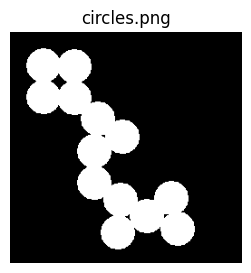

In [4]:
img_path = r"C:\Users\loann\Desktop\cv2\Images\circles.png"
if not os.path.exists(img_path):
    print(f"Error: The file {img_path} does not exist.")
    sys.exit(1)
img = read_image(img_path)
plt.figure(figsize=(6, 3))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('circles.png')
plt.show()

### 1. Introduction

L’érosion est une opération morphologique utilisée en traitement d’images pour **réduire la taille des objets clairs** dans une image binaire ou en niveaux de gris.  
Elle permet de **supprimer les petits bruits**, **séparer des objets connectés**, ou **affiner les contours**.

L’opération repose sur un **élément structurant**, généralement une petite matrice (par exemple 3×3) mais peut avoir une forme différente, qui détermine la manière dont les pixels sont supprimés.


### 2. Création de l’élément structurant

L’élément structurant est un petit motif qui sert de base à l’érosion.  
Dans cet exemple, on utilise un **carré 3×3**.


### Remarque :
 Si les objets ne sont pas bien séparés après une érosion, il faut augmenter le nombre d’itérations ou la taille de l’élément structurant.


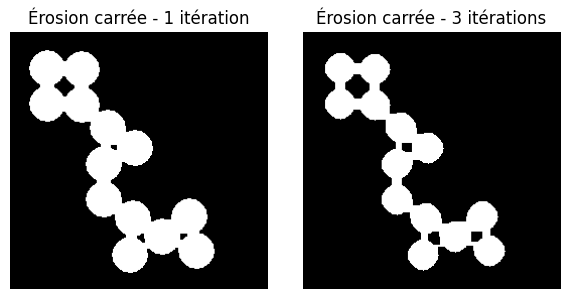

In [5]:
# Création d’un élément structurant carré 3×3
Str1 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# Érosion simple (1 itération)
eroded_once = cv2.erode(img, Str1)

# Érosion avec plusieurs itérations (ici 3)
eroded_multiple = cv2.erode(img, Str1, iterations=3)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(cv2.cvtColor(eroded_once, cv2.COLOR_BGR2RGB))
axes[0].set_title('Érosion carrée - 1 itération')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(eroded_multiple, cv2.COLOR_BGR2RGB))
axes[1].set_title('Érosion carrée - 3 itérations')
axes[1].axis('off')

plt.tight_layout()
plt.show()


### 3. Passage à une érosion circulaire

Après avoir étudié l’érosion carrée, on applique maintenant une **érosion circulaire**.  
Cette méthode repose sur un **élément structurant de forme elliptique**, qui réalise l’érosion en suivant une géométrie plus arrondie que le carré.

L’intérêt principal de cette approche est de **préserver la forme circulaire** ou ovale des objets présents dans l’image.  
Elle est donc particulièrement adaptée pour le traitement d’images contenant des **particules, cellules ou motifs circulaires**, où une érosion trop anguleuse pourrait déformer les contours.


### 4. Analyse et comparaison

L’érosion circulaire est généralement **moins agressive** que l’érosion carrée.  
Les contours sont adoucis, et la perte de matière sur les bords est plus progressive.  
Cependant, cette douceur se traduit aussi par une **moindre efficacité** pour séparer les objets très proches ou collés.

Ainsi, si les éléments ne sont pas encore bien distincts après une seule érosion circulaire, il est nécessaire de :
- **augmenter le nombre d’itérations**, afin de renforcer l’effet ;
- ou **utiliser un élément structurant de taille plus grande** (par exemple 5×5).


### 5. Conclusion

L’érosion circulaire permet une meilleure conservation des formes naturelles mais offre une action plus douce.  
Dans le cas de l’image étudiée, un **élément circulaire de taille 3×3** n’est **pas suffisant** pour séparer efficacement les objets.  
Le carré reste plus performant pour la séparation, tandis que le cercle est préférable pour préserver la géométrie des objets.

Le **choix de la forme** et de la **taille** de l’élément structurant dépend donc étroitement de la **morphologie** des éléments présents dans l’image et du **résultat souhaité**.


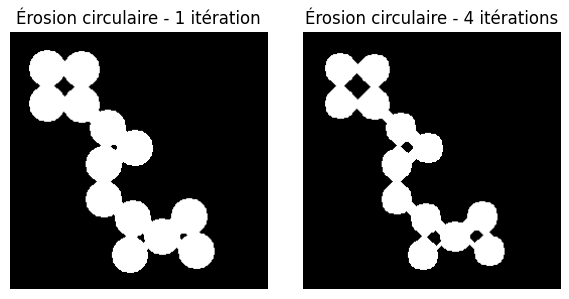

In [6]:
# Création d’un élément structurant circulaire (3×3)
Str2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

# Érosion simple (1 itération)
eroded_once_circ = cv2.erode(img, Str2)

# Érosion avec plusieurs itérations (ici 4)
eroded_multiple_circ = cv2.erode(img, Str2, iterations=4)

# Affichage côte à côte pour comparaison
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(cv2.cvtColor(eroded_once_circ, cv2.COLOR_BGR2RGB))
axes[0].set_title('Érosion circulaire - 1 itération')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(eroded_multiple_circ, cv2.COLOR_BGR2RGB))
axes[1].set_title('Érosion circulaire - 4 itérations')
axes[1].axis('off')

plt.tight_layout()
plt.show()



### 6. Possibilité d’obtenir le résultat en une seule érosion

L’efficacité d’une seule érosion dépend principalement de deux facteurs :  
la **taille de l’élément structurant** et la **proximité des objets** dans l’image.

Si l’élément structurant utilisé est **trop petit**, une seule itération ne permet généralement pas de séparer complètement les objets.  
En revanche, en **augmentant la taille** de cet élément (par exemple 5×5 ou 7×7 au lieu de 3×3), il devient possible d’obtenir un résultat équivalent à plusieurs érosions successives.

Ainsi, pour atteindre le résultat souhaité en une seule étape, il faut **adapter la taille et la forme** de l’élément structurant à la géométrie des objets.  

Un élément structurant **plus large** agit sur une zone plus grande et produit un effet d’érosion plus marqué, capable de séparer les objets dès la première application.


### 7. Conclusion

Oui, il est **possible** d’obtenir le résultat désiré avec une seule érosion, **à condition d’utiliser un élément structurant suffisamment grand**.  
Cependant un élément trop grand risque d’**altérer la forme** ou de **faire disparaître** les petits objets.  

Le choix du bon compromis entre **taille**, **forme**, et **nombre d’itérations** dépend donc du but recherché et de la structure de l’image.


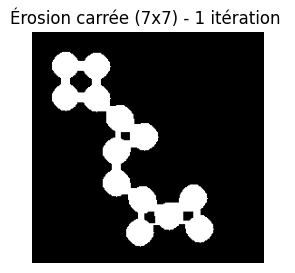

In [7]:
# Test avec un élément structurant plus grand (7x7)
large_str = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
eroded_large_once = cv2.erode(img, large_str)

plt.figure(figsize=(6, 3))
plt.imshow(cv2.cvtColor(eroded_large_once, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Érosion carrée (7x7) - 1 itération ')
plt.show()

### 8. Étiquetage des objets après érosion

Avant de pouvoir compter ou analyser les objets d’une image, il est souvent nécessaire de **séparer les éléments collés**.  
Pour cela, une érosion carrée est appliquée afin de **rompre les connexions** entre objets voisins.

Dans cette expérience, un élément structurant de **7×7** et **trois itérations** a été utilisée. 
Cette configuration permet de renforcer l’effet d’érosion pour pouvoir compter le nombre d'objets.
Après cette étape, les objets deviennent bien distincts les uns des autres, ce qui facilite leur identification.

Une fois les objets séparés, la fonction d’étiquetage permet d’attribuer un **numéro unique à chaque région connectée**, équivalente à la fonction **bwlabel** de MATLAB.  
Ainsi, chaque objet de l’image est isolé et peut être visualisé avec une couleur différente.

### 9. Analyse du résultat

L’érosion préalable a permis d’obtenir une **bonne séparation des objets** avant l’étiquetage.  
Le nombre d'objets detectés après érosion est de **13**


Nombre d'objets détectés après érosion : 13


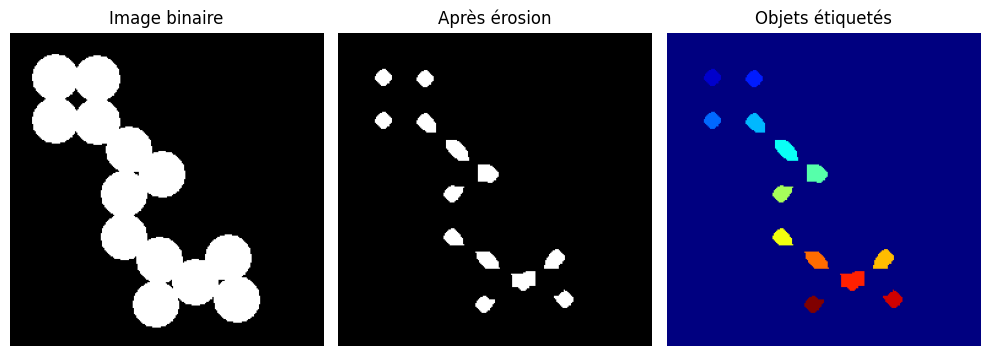

In [8]:

# Conversion en niveaux de gris
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Seuillage pour obtenir une image binaire 
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Érosion pour séparer les objets collés 
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))  # carré 7x7
eroded = cv2.erode(binary, kernel, iterations=3)  # 3 itérations

# Étiquetage des objets
labeled, num_objects = ndimage.label(eroded)

print(f"Nombre d'objets détectés après érosion : {num_objects}")

# Génération d'une image colorée pour visualisation
labeled_color = cv2.applyColorMap(
    cv2.convertScaleAbs((labeled * 255 / np.max(labeled)).astype(np.uint8)),
    cv2.COLORMAP_JET
)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

axes[0].imshow(binary, cmap='gray')
axes[0].set_title('Image binaire')
axes[0].axis('off')

axes[1].imshow(eroded, cmap='gray')
axes[1].set_title('Après érosion')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(labeled_color, cv2.COLOR_BGR2RGB))
axes[2].set_title('Objets étiquetés')
axes[2].axis('off')

plt.tight_layout()
plt.show()


---
## Deuxième partie : Ouverture et fermeture

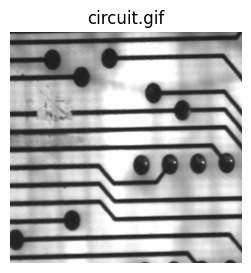

In [9]:
image_path = r"C:\Users\loann\Desktop\cv2\Images\circuit.gif"
if not os.path.exists(image_path):
    print(f"Error: The file {image_path} does not exist.")
    sys.exit(1)
img = read_image(image_path)
plt.figure(figsize=(6, 3))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('circuit.gif')
plt.show()




### 10. Objectif
Le but est de supprimer un défaut localisé (cassure et irrégularité) sur l’image **circuit.gif** tout en **préservant la géométrie** des pistes du circuit imprimé.

### 11. Données et pré-traitement
- **Image** : `circuit.gif` (chargée en niveaux de gris).
- **Pré-traitement** :
  - Flou gaussien `(3×3)` pour réduire le bruit.
  - **Seuillage d’Otsu et une inversion** pour avoir des **pistes blanches** sur fond noir

### 12. Opérations
Deux opérations sont enchaînées :

1) **Fermeture (Closing)** = *dilatation suivie d’érosion*  
   - **Structurant** : **rectangulaire horizontal `21×3`**  
   - **Rôle** : combler les cassures **le long des pistes** sans gonfler verticalement.

2) **Ouverture (Opening)** = *érosion suivie de dilatation*  
   - **Structurant** : **elliptique `3×3`**  
   - **Rôle** : supprimer les petits artefacts résiduels et adoucir légèrement les contours.

Enfin, on inverse pour revenir à des **pistes noires** sur fond blanc.


### 13. Observation 
La fermeture (21×3) a bien comblé le défaut principal (cassure/irrégularité) et rétabli la continuité des pistes.

**Effets indésirables observés** : léger épaississement de certaines pistes, petits ponts créés entre éléments proches et fusion locale de détails fins.
Ces artefacts proviennent probablement d’un structurant trop long et épais pour certaines zones, et l’ouverture 3×3 ne suffit pas toujours à annuler ces ajouts.

### 14. Conclusion
La chaîne atteint l’objectif de combler le défaut ciblé, mais introduit d’autres défauts dans les régions denses.

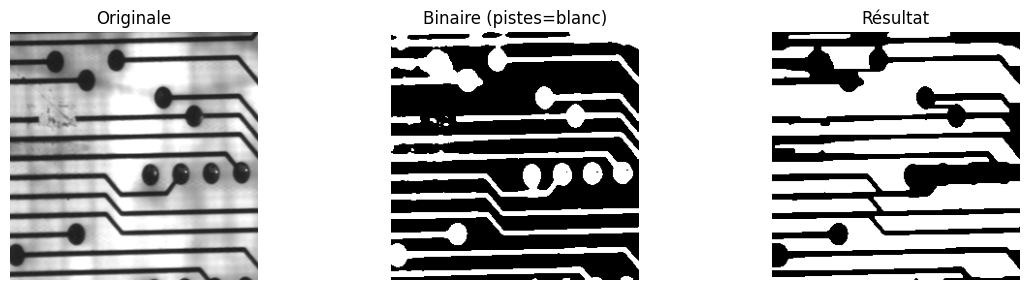

In [10]:
IMG_PATH = r"C:\Users\loann\Desktop\cv2\Images\circuit.gif"

# Lecture en niveaux de gris
img = cv2.imread(IMG_PATH, cv2.IMREAD_GRAYSCALE)
assert img is not None, "Image introuvable"

# Binarisation (Otsu) + inversion : pistes en blanc
b = cv2.threshold(cv2.GaussianBlur(img, (3, 3), 0), 0, 255,
                  cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]

# Morphologie : fermeture horizontale (21x3) puis ouverture (3x3) 
closed = cv2.morphologyEx(b, cv2.MORPH_CLOSE,
                          cv2.getStructuringElement(cv2.MORPH_RECT, (21, 3)))
opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN,
                          cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))

# Retour aux pistes noires
out = cv2.bitwise_not(opened)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); 
plt.imshow(img, cmap='gray'); 
plt.title("Originale"); 
plt.axis('off')
plt.subplot(1,3,2); 
plt.imshow(b, cmap='gray');   
plt.title("Binaire (pistes=blanc)"); 
plt.axis('off')
plt.subplot(1,3,3); 
plt.imshow(out, cmap='gray'); 
plt.title("Résultat"); 
plt.axis('off')
plt.tight_layout(); 
plt.show()



### 15. Chargement et affichage de `circles.png`

* Ouvrir l’image en **niveaux de gris**.
* Binariser avec **Otsu**.
* Inverser pour avoir les **objets en blanc**.

### 16. Opérations *bwmorph*

* **bothat** : met en évidence les **creux sombres** dans des objets clairs. Idéal pour **localiser** une cassure interne. Et il est très **sensible** à la taille du structurant.
<br><br>

* **clean** : supprime les **pixels/îlots isolés**. Parfait contre le **sel/poivre léger** et n’altère quasiment pas les grandes formes.
<br><br>

* **close** : **comble** trous/fissures et favorise la **reconnection**. Toutefois il y a un risque d’**épaissir** si l’élément structurant est trop grand (préférer anisotrope, ex. 21×3).
<br><br>

* **dilate** : **épaissit** et **colmate** de petits gaps. Il est utile avant une fermeture et peut **fusionner** des objets proches.
<br><br>

* **erode** : **amincit** et peut **séparer** des liaisons fines. Il est bon pour enlever les bavures. Mais il faut faire attention aux **ruptures** involontaires.
<br><br>

* **hbreak** : tente de **casser les ponts** en “H” (traverse mince entre deux barres). Il marche surtout si la traverse est **fine et alignée**. 
<br><br>

* **majority** : réduit bien le **bruit dense** sans trop déformer. Il peut **adoucir** légèrement les bords.
<br><br>

* **open** : **élague** pointes/bavures et isole petits collages. Il amincit un peu les traits.
<br><br>

* **remove** : conserve les **contours**. Utile pour un **diagnostic** d’épaisseur/continuité, mais pas une correction.
<br><br>

* **thicken** : **épaissit** (itérations de dilatation). Il est utile pour les traits trop fins mais demeure un **fort risque de ponts**.
<br><br>

* **thin** : **squelettise** à 1 px. Top pour la **connectivité/mesures d’axes**.Par conséquant, on perd l’info d’épaisseur.




C:\Users\loann\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skimage\exposure\exposure.py:306: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist, bin_edges = np.histogram(image, bins=bins, range=hist_range)
C:\Users\loann\AppData\Local\Temp\ipykernel_25812\1928242404.py:5: FutureWarning: `rectangle` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  def footprint_rectangle(m, n): return rectangle(m, n)


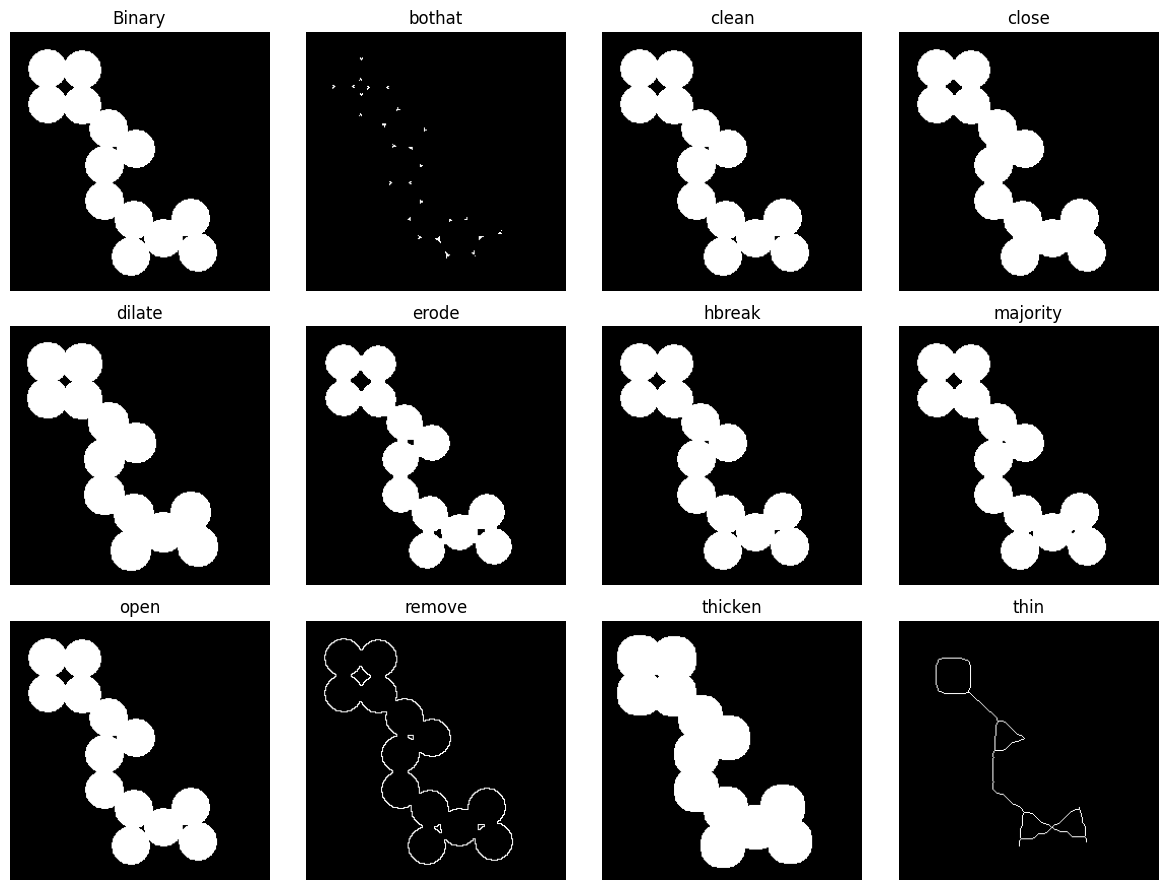

In [11]:

try:
    from skimage.morphology import footprint_rectangle, footprint_disk
except Exception:
    from skimage.morphology import rectangle, disk
    def footprint_rectangle(m, n): return rectangle(m, n)
    def footprint_disk(r): return disk(r)

def rect(k):
    """
    Carré k x k (pour close/open/dilate/erode/majority).
    """
    return footprint_rectangle(k, k)

def circ(r):
    """
    Disque de rayon r (pour bothat).
    """
    return footprint_disk(r)

img_path = r"C:\Users\loann\Desktop\cv2\Images\circles.png"
img = io.imread(img_path)  

if img.ndim == 3:                         # si RGB, on convertit en gris
    from skimage.color import rgb2gray
    img = (rgb2gray(img) * 255).astype(np.uint8)

th = filters.threshold_otsu(img)          # seuil automatique
BW = img > th                             # booléen : objets = True
#BW = ~BW                                 # on inverse si besoin (objets=blanc)


def bothat(im, radius=3):
    """
    Bottom-hat (met en évidence des creux sombres).
    """
    out = morphology.black_tophat(im.astype(np.uint8) * 255, footprint=circ(radius))
    return out > 0                         # renvoie booléen


def clean(im):
    """
    Supprime les pixels blancs isolés (composantes de taille 1).
    """
    return morphology.remove_small_objects(im, min_size=2)


def close(im, k=3):
    """
    Fermeture : comble petits trous/ruptures (dilatation puis érosion).
    """
    return morphology.binary_closing(im, footprint=rect(k))


def open_(im, k=3):
    """
    Ouverture : enlève petites saillies/points (érosion puis dilatation).
    """
    return morphology.binary_opening(im, footprint=rect(k))


def dilate(im, k=3):
    """
    Dilatation : épaissit et connecte localement.
    """
    return morphology.binary_dilation(im, footprint=rect(k))


def erode(im, k=3):
    """
    Érosion : amincit et peut créer des séparations fines.
    """
    return morphology.binary_erosion(im, footprint=rect(k))


def remove(im):
    """
    Contours uniquement : A \ (A érodé).
    """
    return im & ~morphology.binary_erosion(im, footprint=rect(3))


def thin(im):
    """
    Amincissement (squelettisation 1 pixel).
    """
    return morphology.thin(im)


def thicken(im, n=3):
    """
    Épaississement grossier (dilatation répétée n fois).
    """
    out = im.copy()
    for _ in range(n):
        out = morphology.binary_dilation(out, footprint=rect(3))
    return out


def hbreak(im):
    """
    'hbreak' (approximation) : casse des ponts en forme de 'H'.
    Supprime des pixels qui relient deux barres parallèles via une traverse.
    (Implémentation simple par motifs locaux : pédagogique, pas universelle.)
    """
    U  = np.roll(im, -1, 0); D  = np.roll(im,  1, 0)
    L  = np.roll(im, -1, 1); R  = np.roll(im,  1, 1)
    UL = np.roll(U, -1, 1); UR = np.roll(U,  1, 1)
    DL = np.roll(D, -1, 1); DR = np.roll(D,  1, 1)
    C  = im
    # pont horizontal (traverse d’un H)
    mask_h = C & L & R & UL & DL & UR & DR & (~U) & (~D)
    # pont vertical (même logique, rot. 90°)
    mask_v = C & U & D & UL & UR & DL & DR & (~L) & (~R)
    return im & ~(mask_h | mask_v)

def majority(im):
    """
    Filtre 'majority' 3 x 3 : remplace un pixel par la valeur majoritaire
    de son voisinage (vote). Très efficace contre le bruit sel/poivre.
    (rank.majority attend du uint8.)
    """
    u8 = (im.astype(np.uint8) * 255)
    return rank.majority(u8, footprint=rect(3)) > 0

# lancer chaque opération et afficher une grille de résultats
ops = {
    "bothat":   lambda B: bothat(B).astype(np.uint8),  # rendu plus visible
    "clean":    lambda B: clean(B),
    "close":    lambda B: close(B),
    "dilate":   lambda B: dilate(B),
    "erode":    lambda B: erode(B),
    "hbreak":   lambda B: hbreak(B),
    "majority": lambda B: majority(B),
    "open":     lambda B: open_(B),
    "remove":   lambda B: remove(B),
    "thicken":  lambda B: thicken(B, n=3),
    "thin":     lambda B: thin(B),
}

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.ravel()
axes[0].imshow(BW, cmap='gray'); axes[0].set_title("Binary"); axes[0].axis('off')

for ax, (name, fn) in zip(axes[1:], ops.items()):
    R = fn(BW)
    ax.imshow(R, cmap='gray')
    ax.set_title(name); ax.axis('off')

plt.tight_layout(); plt.show()


### 18. Bruit « Salt & Pepper » + filtre **majority**

* **But** : ajouter un bruit impulsionnel (**sel & poivre**) à `circles.png`, puis le **corriger** avec le filtre **majority** pour retrouver des objets propres sans déformer la géométrie.

  <br>

* **Procédure** :

  1. Charger l’image **grayscale** d’origine.
  2. Ajouter un bruit **Salt & Pepper** de densité modérée (p ≈ 5–10 %).
  3. **Binariser** (Otsu), puis **inverser** pour avoir les objets en **blanc**.
  4. Appliquer **majority 3×3** une **seule passe**.
  6. Visualiser : binaire, binaire bruitée, majority×1.

     <br>

* **Résultats attendus** :

  * **majority ×1** : supprime efficacement la **majorité des pixels isolés** (sel/poivre), **préserve** les contours des cercles.
  * Si le bruit est **trop dense** ou les contours **très fins**, on observe un **sur-lissage**.

    <br>

* **Discussion** :

  * **majority** est **robuste** quand le bruit impulsionnel est **répandu**. Il peut **adoucir** les bords.
  * Une seule passe suffit **"souvent"**. Multiplier les passes **améliore** la propreté mais **altère** davantage la géométrie.

    <br>

C:\Users\loann\AppData\Local\Temp\ipykernel_25812\809591814.py:14: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  maj1 = rank.majority(BW_noisy.astype('uint8')*255, footprint=square(3)) > 0


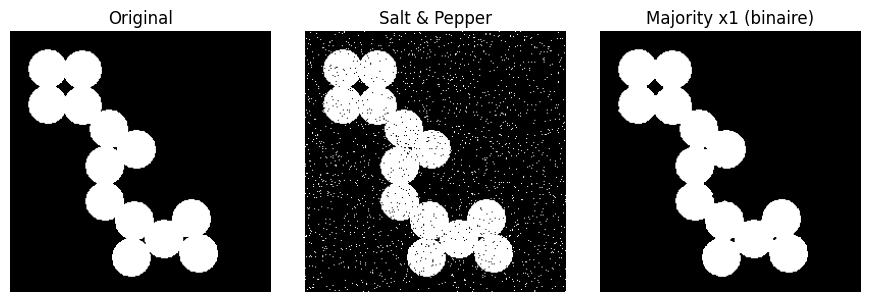

In [17]:
img = io.imread(r"C:\Users\loann\Desktop\cv2\Images\circles.png")
if img.ndim == 3:
    img = (rgb2gray(img)*255).astype('uint8')

# Bruit Salt & Pepper
noisy = (util.random_noise(img, mode='s&p', amount=0.06)*255).astype('uint8')

# Binarisation 
BW_noisy = noisy > filters.threshold_otsu(noisy)

# Filtre majority (une seule passe, 3x3)
from skimage.filters import rank
from skimage.morphology import square
maj1 = rank.majority(BW_noisy.astype('uint8')*255, footprint=square(3)) > 0

# Affichage
fig, ax = plt.subplots(1,3, figsize=(9,3))
ax[0].imshow(img, cmap='gray');      
ax[0].set_title('Original'); 
ax[0].axis('off')
ax[1].imshow(noisy, cmap='gray');    
ax[1].set_title('Salt & Pepper'); 
ax[1].axis('off')
ax[2].imshow(maj1, cmap='gray');     
ax[2].set_title('Majority x1 (binaire)'); 
ax[2].axis('off')
plt.tight_layout(); plt.show()
